# CMSE 402 Semester Project - The Big-Fish-Little-Pond Effect
## Mikel Good 

In [1]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
from pandas.plotting import parallel_coordinates
from sklearn.preprocessing import MinMaxScaler

In [2]:
# data
mrc_10 = pd.read_csv("data_files/mrc_table10.csv")

### Median Income By Tier Graph

In [3]:
barron_data = {}

for _, row in mrc_10.iterrows():
    barron = row["barrons"]
    med_earn = row["scorecard_median_earnings_2011"]

    if pd.notna(med_earn):
        inst_type = ""
        if barron == 1:
            inst_type = "Elite"
        elif barron == 2:
            inst_type = "Highly Selective"
        elif barron == 3 or barron == 4 or barron == 5:
            inst_type = "Selective"
        elif barron == 9:
            inst_type = "Special"
        elif barron == 999:
            inst_type = "Non-selective"
    
        if inst_type != "":
            if inst_type not in barron_data:
                barron_data[inst_type] = {"tot_med_earn": med_earn, "count": 1, "med_earn_dist": [med_earn]}
            else:
                barron_data[inst_type]["tot_med_earn"] += med_earn
                barron_data[inst_type]["count"] += 1
                barron_data[inst_type]["med_earn_dist"].append(med_earn)

In [4]:
for inst_type, vals in barron_data.items():
    barron_data[inst_type]["avg_med_earn"] = round(vals["tot_med_earn"] / vals["count"], 3)

barron_df = pd.DataFrame(barron_data).T.reset_index()
barron_df.rename(columns={"index": "Institution Type"}, inplace=True)

In [5]:
barron_df

,Institution Type,tot_med_earn,count,med_earn_dist,avg_med_earn
0,Non-selective,34362909.11,1164,"[26400.0, 31900.0, 36100.0, 32300.0, 22000.0, ...",29521.4
1,Selective,41729663.907,1016,"[40200.0, 33200.0, 50600.0, 36500.0, 31400.0, ...",41072.504
2,Special,1430600.0,34,"[51100.0, 110600.0, 51700.0, 33000.0, 39800.0,...",42076.471
3,Highly Selective,5070847.516,98,"[39400.0, 55900.0, 49600.0, 47600.0, 85500.0, ...",51743.342
4,Elite,4746800.0,77,"[56800.0, 57400.0, 53500.0, 67000.0, 54800.0, ...",61646.753


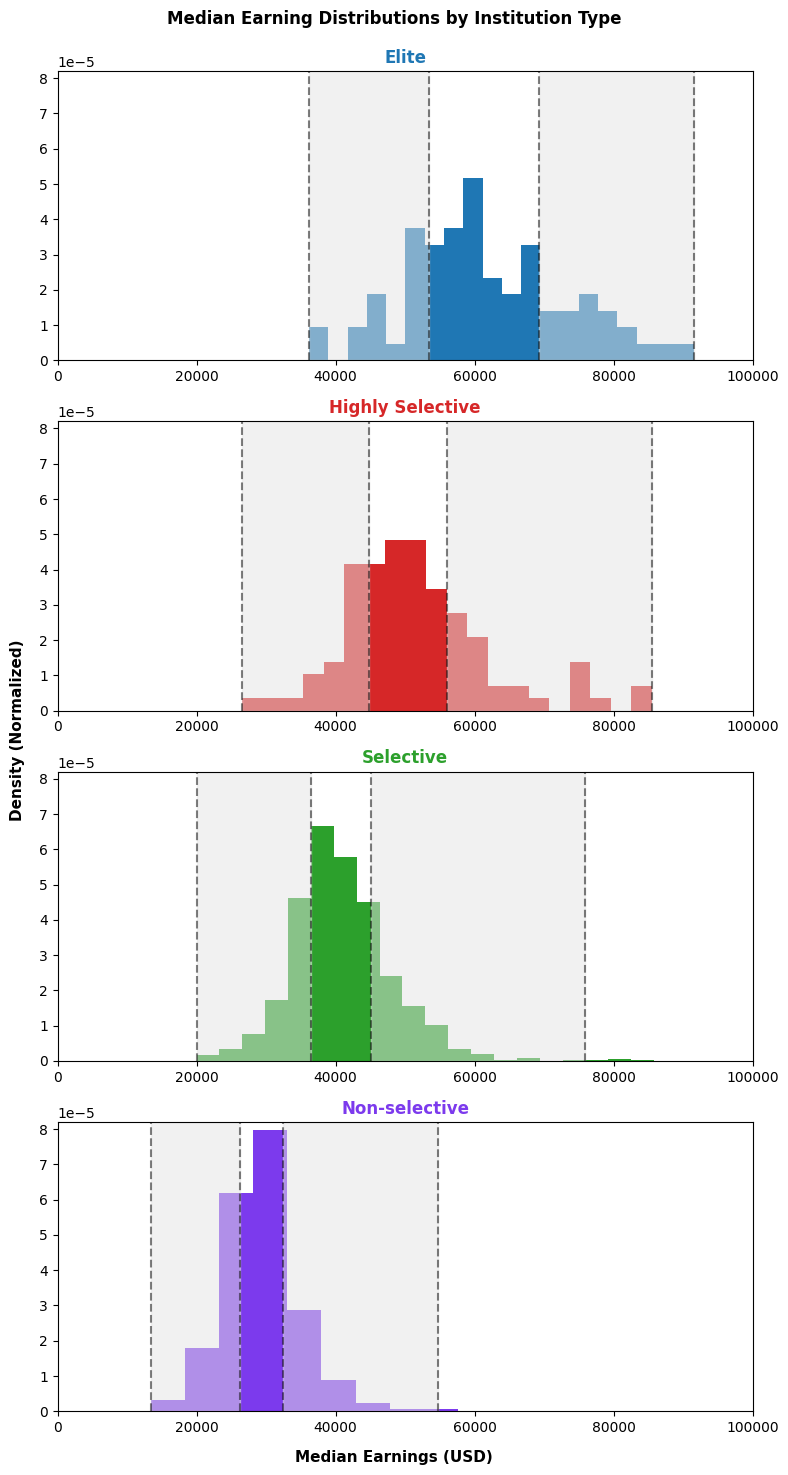

In [7]:
# Note: Institutions of "Special" classification are not displayed
# This is because they have a relatively small amount of data
fig, axes = plt.subplots(4, 1, figsize=(8, 15))

# Graph 1 - Elite
elite = barron_df["med_earn_dist"][4]
min_el = np.percentile(elite, 0)
q1_el = np.percentile(elite, 25)
q3_el = np.percentile(elite, 75)
max_el = np.percentile(elite, 100)

axes[0].hist(elite, density=True, bins=20,
            color="#1f77b4")
axes[0].set_xlim(0, 10e4)
axes[0].set_ylim(0, 8.2e-5)
axes[0].set_title("Elite", fontweight="bold", color="#1f77b4")
axes[0].axvline(min_el, color="black", alpha=0.5, linestyle="--")
axes[0].axvline(q1_el, color="black", alpha=0.5, linestyle="--")
axes[0].axvline(q3_el, color="black", alpha=0.5, linestyle="--")
axes[0].axvline(max_el, color="black", alpha=0.5, linestyle="--")
axes[0].axvspan(min_el, q1_el, color="#E5E5E5", alpha=0.5)
axes[0].axvspan(q3_el, max_el, color="#E5E5E5", alpha=0.5)


# Graph 2 - Highly Selective
high_select = barron_df["med_earn_dist"][3]
min_hs = np.percentile(high_select, 0)
q1_hs = np.percentile(high_select, 25)
q3_hs = np.percentile(high_select, 75)
max_hs = np.percentile(high_select, 100)

axes[1].hist(high_select, density=True, bins=20,
            color="#d62728")
axes[1].set_xlim(0, 10e4)
axes[1].set_ylim(0, 8.2e-5)
axes[1].set_title("Highly Selective", fontweight="bold", color="#d62728")
axes[1].axvline(min_hs, color="black", alpha=0.5, linestyle="--")
axes[1].axvline(q1_hs, color="black", alpha=0.5, linestyle="--")
axes[1].axvline(q3_hs, color="black", alpha=0.5, linestyle="--")
axes[1].axvline(max_hs, color="black", alpha=0.5, linestyle="--")
axes[1].axvspan(min_hs, q1_hs, color="#E5E5E5", alpha=0.5)
axes[1].axvspan(q3_hs, max_hs, color="#E5E5E5", alpha=0.5)

# Graph 3 - Selective
select = barron_df["med_earn_dist"][1]
min_s = np.percentile(select, 0)
q1_s = np.percentile(select, 25)
q3_s = np.percentile(select, 75)
max_s = np.percentile(select, 99.65)

axes[2].hist(select, density=True, bins=20,
            color="#2ca02c")
axes[2].set_xlim(0, 10e4)
axes[2].set_ylim(0, 8.2e-5)
axes[2].set_title("Selective", fontweight="bold", color="#2ca02c")
axes[2].axvline(min_s, color="black", alpha=0.5, linestyle="--")
axes[2].axvline(q1_s, color="black", alpha=0.5, linestyle="--")
axes[2].axvline(q3_s, color="black", alpha=0.5, linestyle="--")
axes[2].axvline(max_s, color="black", alpha=0.5, linestyle="--")
axes[2].axvspan(min_s, q1_s, color="#E5E5E5", alpha=0.5)
axes[2].axvspan(q3_s, max_s, color="#E5E5E5", alpha=0.5)

# Graph 4 - Non-selective
non_select = barron_df["med_earn_dist"][0]
min_ns = np.percentile(non_select, 0)
q1_ns = np.percentile(non_select, 25)
q3_ns = np.percentile(non_select, 75)
max_ns = np.percentile(non_select, 99.9)
axes[3].hist(non_select, density=True, bins=20,
            color="#7c3aed")
axes[3].set_xlim(0, 10e4)
axes[3].set_ylim(0, 8.2e-5)
axes[3].set_title("Non-selective", fontweight="bold", color="#7c3aed")
axes[3].axvline(min_ns, color="black", alpha=0.5, linestyle="--")
axes[3].axvline(q1_ns, color="black", alpha=0.5, linestyle="--")
axes[3].axvline(q3_ns, color="black", alpha=0.5, linestyle="--")
axes[3].axvline(max_ns, color="black", alpha=0.5, linestyle="--")
axes[3].axvspan(min_ns, q1_ns, color="#E5E5E5", alpha=0.5)
axes[3].axvspan(q3_ns, max_ns, color="#E5E5E5", alpha=0.5)

plt.suptitle("Median Earning Distributions by Institution Type\n", fontweight="bold")
fig.supylabel("Density (Normalized)", fontsize=11, fontweight='bold')
fig.supxlabel("Median Earnings (USD)", fontsize=11, fontweight="bold")
fig.tight_layout()
fig.savefig("viz_files/Median_Income_By_Tier.png", dpi=400)
fig.show()

In [9]:
barron_df

,Institution Type,tot_med_earn,count,med_earn_dist,avg_med_earn
0,Non-selective,34362909.11,1164,"[26400.0, 31900.0, 36100.0, 32300.0, 22000.0, ...",29521.4
1,Selective,41729663.907,1016,"[40200.0, 33200.0, 50600.0, 36500.0, 31400.0, ...",41072.504
2,Special,1430600.0,34,"[51100.0, 110600.0, 51700.0, 33000.0, 39800.0,...",42076.471
3,Highly Selective,5070847.516,98,"[39400.0, 55900.0, 49600.0, 47600.0, 85500.0, ...",51743.342
4,Elite,4746800.0,77,"[56800.0, 57400.0, 53500.0, 67000.0, 54800.0, ...",61646.753


In [10]:
dists = [
    barron_df["med_earn_dist"][4],   
    barron_df["med_earn_dist"][3],   
    barron_df["med_earn_dist"][1],   
    barron_df["med_earn_dist"][0]
]

tier_names = ["Elite", "Highly Selective", "Selective", "Non-selective"]
tier_colors = ["#1f77b4", "#d62728", "#2ca02c", "#7c3aed"]

# Percentile caps
percentile_caps = [100, 100, 99.65, 99.9]

fig = plt.figure(figsize=(10, 8))

for i in range(4):

    data = dists[i]
    color = tier_colors[i]
    name = tier_names[i]
    cap = percentile_caps[i]

    min_v = np.percentile(data, 0)
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    max_v = np.percentile(data, cap)

    fig.clf()
    ax = fig.add_subplot(1, 1, 1)

    ax.hist(data, density=True, bins=20, color=color)

    ax.set_xlim(0, 10e4)
    ax.set_ylim(0, 8.2e-5)

    ax.set_title(name, fontweight="bold", color=color, fontsize=17)

    ax.tick_params(labelsize=15, color="black")

    ax.axvline(min_v, color="black", alpha=0.5, linestyle="--")
    ax.axvline(q1, color="black", alpha=0.5, linestyle="--")
    ax.axvline(q3, color="black", alpha=0.5, linestyle="--")
    ax.axvline(max_v, color="black", alpha=0.5, linestyle="--")

    ax.axvspan(min_v, q1, color="#E5E5E5", alpha=0.5)
    ax.axvspan(q3, max_v, color="#E5E5E5", alpha=0.5)

    plt.suptitle("Median Earning Distributions by Institution Type\n",
                 fontweight="bold", fontsize=20)
    fig.supylabel("Density (Normalized)", fontsize=16, fontweight='bold')
    fig.supxlabel("Median Earnings (USD)", fontsize=16, fontweight="bold")

    plt.savefig("anim_files2/image_{:03d}.png".format(i), dpi=400)

plt.close(fig)

**Command used to create the animation:**
```
ffmpeg -framerate 0.75 -i anim_files2/image_%03d.png anim2.mp4
```

### Violin Plot

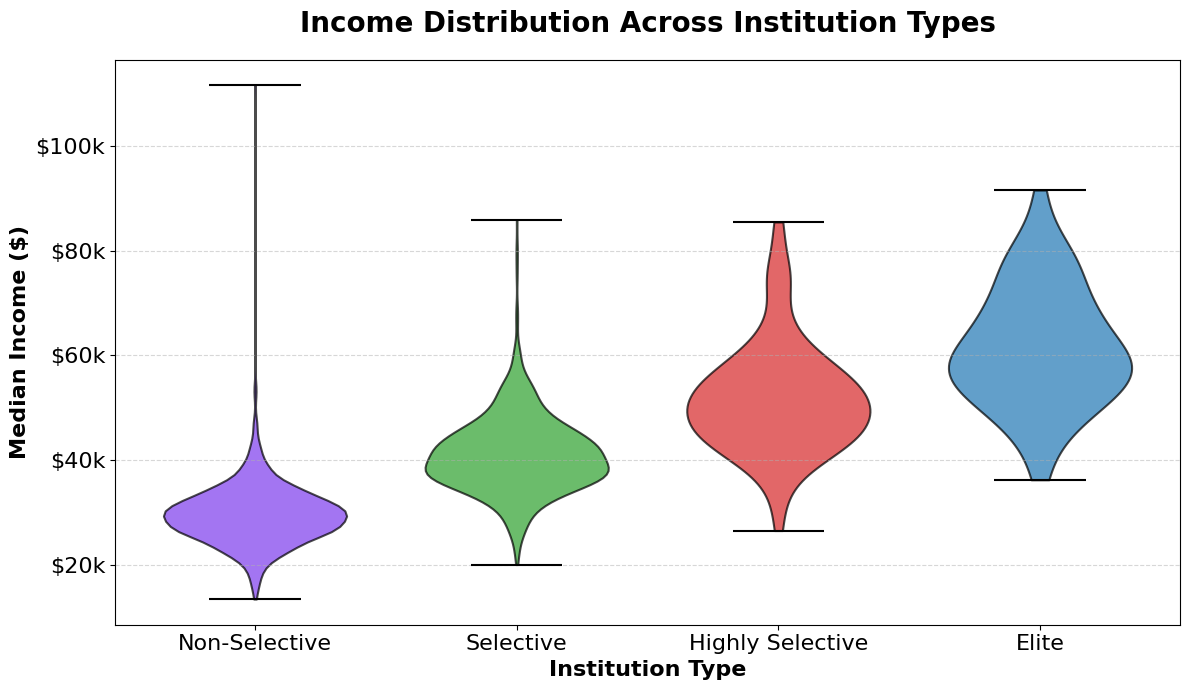

In [11]:
elite_dist = barron_df[barron_df["Institution Type"] == "Elite"] ["med_earn_dist"]
high_select_dist = barron_df[barron_df["Institution Type"] == "Highly Selective"] ["med_earn_dist"]
select_dist = barron_df[barron_df["Institution Type"] == "Selective"] ["med_earn_dist"]
non_select_dist = barron_df[barron_df["Institution Type"] == "Non-selective"] ["med_earn_dist"]

data_by_type = [
    np.concatenate(non_select_dist.values),
    np.concatenate(select_dist.values),
    np.concatenate(high_select_dist.values),
    np.concatenate(elite_dist.values)
    
]

institution_types = ["Non-Selective", "Selective", "Highly Selective", "Elite"]

fig, ax = plt.subplots(figsize=(12, 7))

parts = ax.violinplot(data_by_type, positions=range(len(data_by_type)), widths=0.7)

colors = ["#7c3aed", "#2ca02c", "#d62728", "#1f77b4"]

for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(colors[i])
    pc.set_alpha(0.7)
    pc.set_edgecolor('black')
    pc.set_linewidth(1.5)

parts['cbars'].set_linewidth(0)
parts['cmaxes'].set_color('black')
parts['cmins'].set_color('black')

ax.set_xticks(range(len(institution_types)))
ax.set_xticklabels(institution_types, fontsize=16)
ax.set_ylabel('Median Income ($)', fontsize=16, fontweight='bold')
ax.set_xlabel("Institution Type", fontsize=16, fontweight="bold")
ax.set_title("Income Distribution Across Institution Types", 
             fontsize=20, fontweight='bold', pad=20)

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}k'))
ax.tick_params(axis='y', labelsize=16)

ax.grid(True, alpha=0.5, linestyle='--', axis='y')

plt.tight_layout()
plt.savefig('viz_files/violin_plot.png', dpi=400)
plt.show()

### Average SAT vs Median Earnings (Scatter)

In [7]:
elite = mrc_10[mrc_10["barrons"] == 1]
high_select = mrc_10[mrc_10["barrons"] == 2]
select = mrc_10[mrc_10["barrons"] > 2]
select = select[select["barrons"] < 9]
non_select = mrc_10[mrc_10["barrons"] == 999]

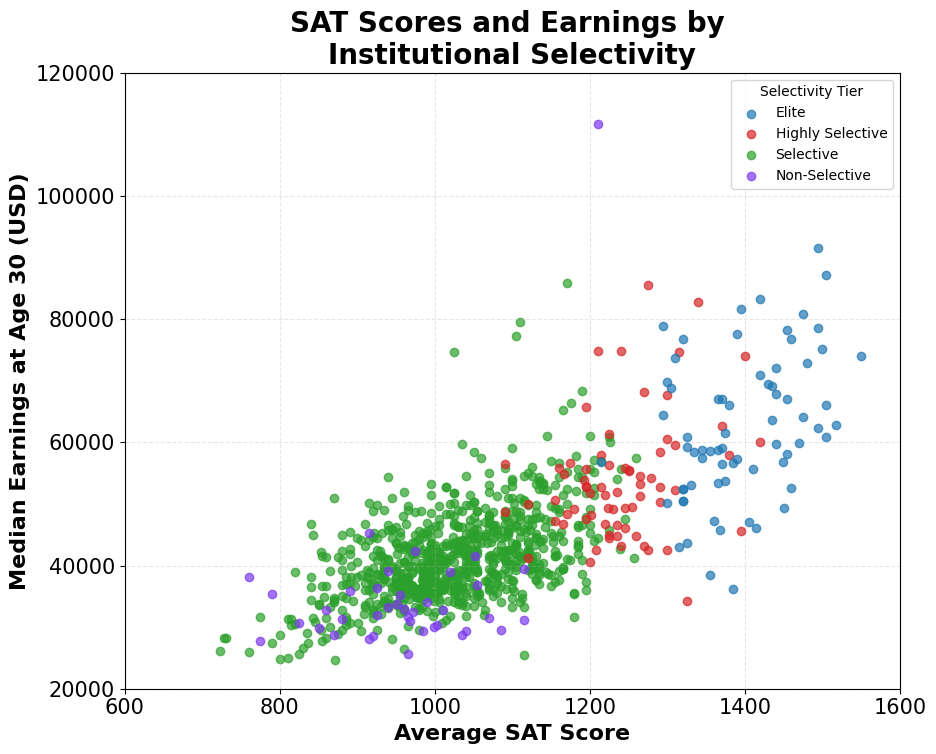

In [9]:
fig = plt.figure(figsize=(10,8))

plt.scatter(elite["sat_avg_2013"], elite["scorecard_median_earnings_2011"], alpha=0.7, color="#1f77b4",
            label="Elite", zorder=4)

plt.scatter(high_select["sat_avg_2013"], high_select["scorecard_median_earnings_2011"], alpha=0.7, color="#d62728",
            label="Highly Selective", zorder=3)

plt.scatter(select["sat_avg_2013"], select["scorecard_median_earnings_2011"], alpha=0.7, color="#2ca02c",
            label="Selective", zorder=1)

plt.scatter(non_select["sat_avg_2013"], non_select["scorecard_median_earnings_2011"], alpha=0.7, color="#7c3aed",
            label="Non-Selective", zorder=2)

plt.xlabel("Average SAT Score", fontweight="bold", fontsize=16)
plt.ylabel("Median Earnings at Age 30 (USD)", fontweight="bold", fontsize=16)
plt.title("SAT Scores and Earnings by \nInstitutional Selectivity", fontweight="bold", fontsize=20)
plt.legend(title="Selectivity Tier")
plt.xlim(600, 1600)
plt.ylim(20000, 1.2e5)

plt.tick_params(labelsize=15, color="black")
plt.grid(alpha=0.3, linestyle="--")

plt.savefig("viz_files/SAT_vs_MED_Earnings_By_Institution.png", dpi=400)
plt.show()

### Choropleth

In [13]:
map_data = {}
for _, row in mrc_10.iterrows():
    state = row["state"]
    avg_sat = row["sat_avg_2013"]
    med_earn = row["scorecard_median_earnings_2011"]
    if pd.notna(avg_sat) and pd.notna(med_earn):
        if state not in map_data:
            map_data[state] = {"tot_sat": avg_sat, "tot_earn": med_earn, "count": 1}
        else:
            map_data[state]["tot_sat"] += avg_sat
            map_data[state]["tot_earn"] += med_earn
            map_data[state]["count"] += 1

In [14]:
for state, vals in map_data.items():
    map_data[state]["avg_sat"] = round(vals["tot_sat"] / vals["count"], 3)
    map_data[state]["avg_med_earn"] = round(vals["tot_earn"] / vals["count"], 3)

map_df = pd.DataFrame(map_data).T.reset_index()
map_df.rename(columns={"index": "state"}, inplace=True)

In [15]:
map_df.head()

,state,tot_sat,tot_earn,count,avg_sat,avg_med_earn
0,TX,58429.26560,2398779.215,56.0,1043.380,42835.343
1,GA,38806.50000,1474000.000,38.0,1021.224,38789.474
2,CO,12871.29210,529248.348,12.0,1072.608,44104.029
3,NY,88080.20480,3944775.835,80.0,1101.003,49309.698
4,MI,26110.85571,1056000.000,24.0,1087.952,44000.000


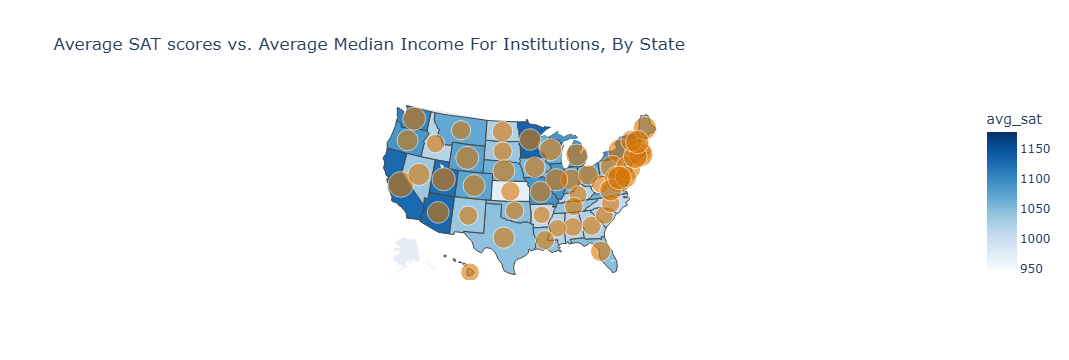

In [48]:
fig = px.choropleth(
    map_df,
    locations="state",
    color="avg_sat",
    locationmode="USA-states",
    projection="albers usa",
    title="Average SAT scores vs. Average Median Income For Institutions, By State",
    hover_data=["state", "avg_sat", "avg_med_earn"],
    color_continuous_scale="blues",
    
)

fig.add_scattergeo(
    locations=map_df["state"],
    locationmode="USA-states",
    marker=dict(
        size=map_df["avg_med_earn"] / 2000,
        color="#d97706", #trying to choose a color that doesn't interfere with the choropleth
        opacity=0.6
    ),
    hoverinfo="skip"
)

fig.write_html("viz_files/SAT_vs_MED_Income.html", include_plotlyjs="cdn")
fig.show()

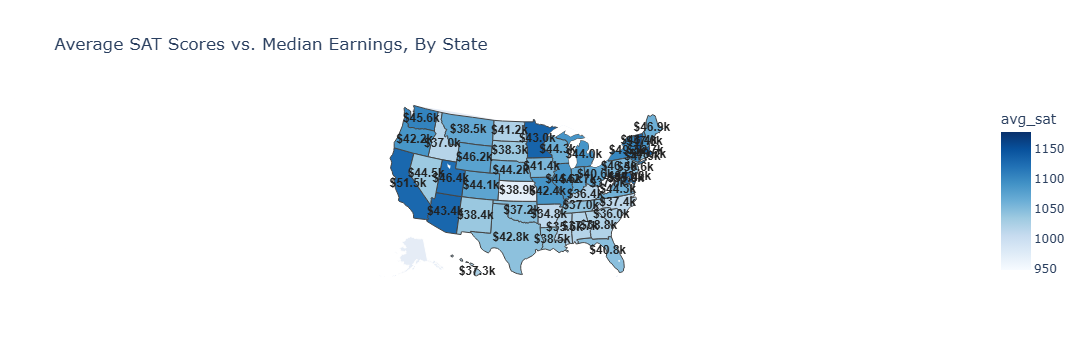

In [49]:
fig = px.choropleth(
    map_df,
    locations="state",
    color="avg_sat",
    locationmode="USA-states",
    projection="albers usa",
    title="Average SAT Scores vs. Median Earnings, By State",
    hover_data=["state", "avg_sat", "avg_med_earn"],
    color_continuous_scale="blues",
)

# Add text labels for median earnings in "$45.6k" format
fig.add_scattergeo(
    locations=map_df["state"],
    locationmode="USA-states",
    text=map_df["avg_med_earn"].apply(lambda x: f"${x/1000:.1f}k"),
    mode="text",
    textfont=dict(
        family="Arial",
        size=12,
        color="#222222",
        weight="bold"
    ),
    hoverinfo="skip"
)

fig.write_html("viz_files/sample.html", include_plotlyjs="cdn")
fig.show()

### Parallel Coordinates Plot

In [25]:
parallel_df = mrc_10[[
    "sat_avg_2013",
    "scorecard_rej_rate_2013",
    "exp_instr_pc_2013",
    "avgfacsal_2013",
    "grad_rate_150_p_2013",
    "scorecard_median_earnings_2011",
    "barrons"
]].dropna()

parallel_df["tier"] = ""

parallel_df["tier"] = np.select(
    [
        parallel_df["barrons"] == 1,
        parallel_df["barrons"] == 2,
        (parallel_df["barrons"] > 2) & (parallel_df["barrons"] < 9),
        parallel_df["barrons"] == 999
    ],
    [
        "Elite",
        "Highly Selective",
        "Selective",
        "Non-Selective"
    ],
    default=""
)

parallel_df = parallel_df[parallel_df["tier"] != ""]
parallel_df.drop(["barrons"], axis=1, inplace=True)
parallel_df = parallel_df.rename(columns={"sat_avg_2013": "SAT", "scorecard_rej_rate_2013": "Rejection Rate",
                                          "exp_instr_pc_2013": "Expenditures per Student", "avgfacsal_2013": "Avg. Faculty Salary",
                                          "grad_rate_150_p_2013": "Grad Rate in 150% of Normal Time", 
                                          "scorecard_median_earnings_2011": "Median Earnings", "tier": "Tier"})
parallel_df.head()

,SAT,Rejection Rate,Expenditures per Student,Avg. Faculty Salary,Grad Rate in 150% of Normal Time,Median Earnings,Tier
1,1075.0,0.5106,7046.2036,5508.0,0.565611,40200.0,Selective
4,984.0,0.4740,5938.9795,5986.0,0.261176,33200.0,Selective
5,1115.0,0.3186,10505.1040,11315.0,0.625142,50600.0,Selective
7,990.0,0.4372,6377.8945,7453.0,0.544513,36500.0,Selective
14,843.5,0.1011,6233.3809,7079.0,0.291383,31400.0,Selective


In [26]:
# Normalize selected columns
cols_to_scale = [
    "SAT",
    "Rejection Rate",
    "Expenditures per Student",
    "Avg. Faculty Salary",
    "Grad Rate in 150% of Normal Time",
    "Median Earnings"
]

scaler = MinMaxScaler()
parallel_df_scaled = parallel_df.copy()
parallel_df_scaled[cols_to_scale] = scaler.fit_transform(parallel_df_scaled[cols_to_scale])

tiers = np.unique(parallel_df_scaled["Tier"])
colors = ["#1f77b4", "#d62728", "#7c3aed", "#2ca02c"]

tier_dfs = []
for i in range(len(tiers)):
    tier = tiers[i]
    masked = parallel_df_scaled[parallel_df_scaled["Tier"] == tier]
    tier_dfs.append(masked)

In [27]:
parallel_df_scaled.head()

,SAT,Rejection Rate,Expenditures per Student,Avg. Faculty Salary,Grad Rate in 150% of Normal Time,Median Earnings,Tier
1,0.425982,0.541406,0.053107,0.165562,0.564239,0.231689,Selective
4,0.316012,0.502598,0.043149,0.193350,0.242484,0.127055,Selective
5,0.474320,0.337822,0.084217,0.503139,0.627157,0.387145,Selective
7,0.323263,0.463578,0.047096,0.278630,0.541942,0.176383,Selective
14,0.146224,0.107200,0.045796,0.256889,0.274409,0.100149,Selective


In [43]:
fig = plt.figure(figsize=(20,12))
for i in range(len(tier_dfs)):
    parallel_coordinates(tier_dfs[i], class_column="Tier", color=colors[i],
                         alpha=0.35, linewidth=1.8)
    plt.ylim(0, 1.1)
    plt.xticks(rotation=12, fontsize=15, fontweight="bold")
    plt.yticks(fontsize=15, fontweight="bold")
    plt.tick_params(size=15, color="black")
    plt.suptitle("Normalized Institutional Characteristics", fontsize=30, 
                 fontweight="bold", y=0.98)
    plt.title(tiers[i], fontsize=22, pad=20, fontweight="bold", color=colors[i])
    plt.legend().remove()
    plt.savefig("anim_files/image_{:03d}.png".format(i), dpi=400)
    fig.clf()

<Figure size 2000x1200 with 0 Axes>

**Command used to create the animation:**
```
ffmpeg -framerate 0.75 -i anim_files/image_%03d.png anim.mp4
```